7 March 2025 2:40PM

In [1]:
import pandas as pd

In [100]:
teams = pd.read_csv('teams.csv')

In [3]:
teams.head()

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [4]:
#remove some of the unwanted columns
teams = teams[['team','country','year','athletes','age','prev_medals','medals']]

In [5]:
#trying to find any relation between medals and any other columns
#teams.corr()['medals']
#the above code results in an error becasue,previous versions of pandas were supporting exlusion of numeric values automatically, now it doesn't. So we use the below code
teams.select_dtypes(include=['number']).corr()['medals']

year          -0.021603
athletes       0.840817
age            0.025096
prev_medals    0.920048
medals         1.000000
Name: medals, dtype: float64

From the above correlation, the athletes and prev_medals has high correlation with the medals

In [7]:
#we'll see it graphically
import seaborn as sns

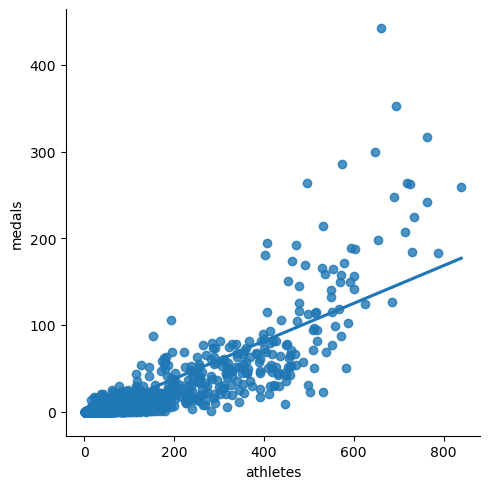

In [96]:
sns.lmplot(x='athletes',y='medals',data=teams,fit_reg=True,ci=None)

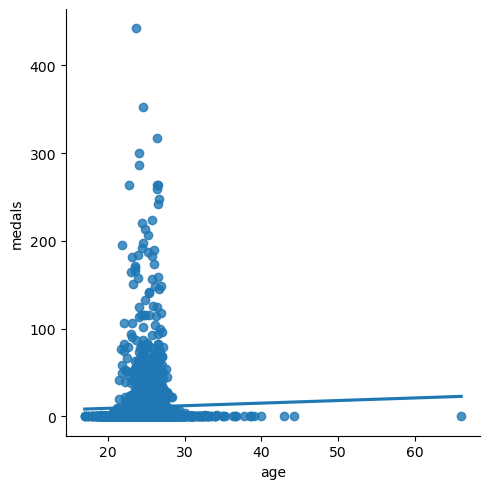

In [9]:
#we'll see a graph which has not high correlation say age and medal
sns.lmplot(x='age',y='medals',data=teams,fit_reg=True,ci=None)

<Axes: ylabel='Frequency'>

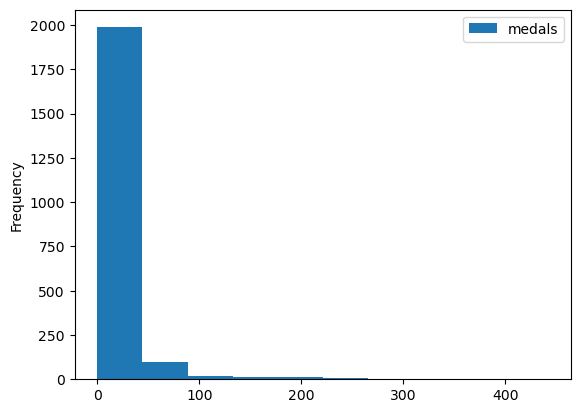

In [15]:
#histogram for how many countries fall into number of medals
teams.plot.hist(y='medals')
#in this graph nearly 2000countries got less than 50 medals and it is reducing on moving further

In [16]:
teams[teams.isnull().any(axis=1)] #it is going to find any missing values in any rows

,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,NaN,0
2103,YAR,North Yemen,1984,3,27.7,NaN,0
2105,YEM,Yemen,1992,8,19.6,NaN,0
2112,YMD,South Yemen,1988,5,23.6,NaN,0


In [17]:
teams = teams.dropna()

In [18]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [19]:
#we are going to split the data into train and test with the condition that the model should predict based on past data not based on future data
train = teams[teams['year'] < 2012].copy()
test = teams[teams['year'] >= 2012].copy()

In [20]:
train.shape

(1609, 7)

In [21]:
test.shape

(405, 7)

The split is similar to 80 - 20 split

In [23]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [24]:
predictors = ['athletes','prev_medals']
target = 'medals'

In [25]:
reg.fit(train[predictors],train[target])

LinearRegression()

In [26]:
predictions = reg.predict(test[predictors])

In [27]:
predictions

array([-9.61221245e-01, -1.17633261e+00, -1.42503158e+00, -1.71184673e+00,
        2.15562926e+00,  3.91463636e+00, -1.71184673e+00, -1.85525431e+00,
        3.67563128e-01, -2.77770967e-01, -1.85525431e+00, -1.49673537e+00,
        4.67519911e+01,  2.87550937e+01,  4.58450091e+00,  2.54773581e+00,
       -1.85525431e+00, -1.64014295e+00, -1.85525431e+00, -1.85525431e+00,
        1.46556876e+02,  1.20571799e+02,  6.56314795e+00,  3.95275254e+00,
        7.34283247e+00,  1.03117468e+01,  5.19171882e+00,  3.58517645e+00,
       -1.64014295e+00, -1.64014295e+00, -1.56843916e+00, -1.20992022e+00,
       -1.71184673e+00, -1.42503158e+00,  1.17929959e+01,  1.00049298e+01,
       -1.78355052e+00, -1.71184673e+00, -1.56843916e+00, -1.56843916e+00,
       -1.99866189e+00, -1.99866189e+00, -1.56843916e+00, -1.35332779e+00,
       -1.92695810e+00, -1.92695810e+00,  3.28912706e+01,  2.53042547e+01,
       -1.78355052e+00, -1.28162400e+00, -1.85525431e+00, -3.87590939e-01,
        7.83480779e+01,  

The problem with our prediction is, it is not a whole number, means a country cannot get a negative number of medals, and he cannot also get medal in decimal like half. So we'll mannually correct it by converting negative to 0 and rounding

In [29]:
#we'll add the predictions as a column to our test data
test['predictions'] = predictions

In [30]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,2.155629
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,-1.926958
2131,ZAM,Zambia,2012,7,22.6,0.0,0,-1.640143
2132,ZAM,Zambia,2016,7,24.1,0.0,0,-1.640143
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,1.505767


In [32]:
#finds the rows with predictions<0 and replace teh predictions to 0
test.loc[test['predictions']<0,'predictions'] = 0
#rounding
test['predictions'] = test['predictions'].round()

In [33]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,2.0


In [35]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(test['medals'], test['predictions'])

In [36]:
error # On an average our prediction is +-3.3 medals 

3.2987654320987656

In [37]:
#we'll findout whether or not it is a good value
teams.describe()['medals']

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [39]:
#make sure your error is less than std, if it is higher then there is certainly a problem. In our case it is ok
#now we'll look team by team
test[test['team'] == 'USA'] #we are not that much far, according to percentage

,team,country,year,athletes,age,prev_medals,medals,predictions
2053,USA,United States,2012,689,26.7,317.0,248,285.0
2054,USA,United States,2016,719,26.4,248.0,264,236.0


In [40]:
#another country, like india, which has not many athelets and prev_medals
test[test['team'] == 'IND'] #but in this case the error is every high, in 2016 our error is high like 6times

,team,country,year,athletes,age,prev_medals,medals,predictions
907,IND,India,2012,95,26.0,3.0,6,7.0
908,IND,India,2016,130,26.1,6.0,2,12.0


In [46]:
#error based on country by country basis
errors = (test['medals'] - test['predictions']).abs()
errors #difference between how many medals we predicted and earned by the team

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [49]:
#now we'll group this by team
error_by_team = errors.groupby(test['team']).mean() #mean value of errors in predicted for a team
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64

8 Mar 2025 9:45PM

In [72]:
# avg medal each country earned
medals_by_team = test['medals'].groupby(test['team']).mean()

In [74]:
error_ratio = error_by_team / medals_by_team
error_ratio #there are lot of NaN values(when 0 / 0) and infinite value(when any number / 0)

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    inf
Length: 204, dtype: float64

In [76]:
# we going to remove those nan
error_ratio[~pd.isnull(error_ratio)] #the ~ negate symbol chooses which is not null

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
ZIM         inf
Length: 102, dtype: float64

In [91]:
# we are going to remove those infinite
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]
error_ratio

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
UKR    0.951220
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

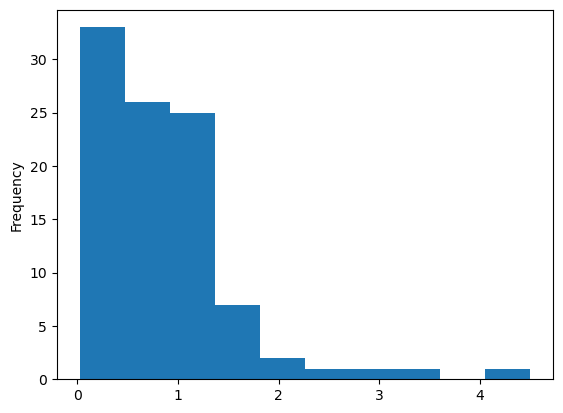

In [89]:
error_ratio.plot.hist() #the plot tells how much the medal prediction is good for the countries
# 0 - 0.5 bin tells within 50% accuracy how many countries are there
# for some countries we are with a low error percentage, whereas for some countries we are having quite high error
# so this model is good for predicting the medals for those countries who are tend to earn lot of medals
# we can improve by, add in more predictors, try different ML models like random forest, NN, different data like specific athlete performance model, try including some columns which had non-linear corelations by using some mathematical transformation which may result us linear corelation, measure error more predictable, different model for different countries like a model of more medal countries and different model for less medal countries